# ChurnZero — Customer Churn Prediction
**Problem**: Predict whether a bank customer will churn (close account / become inactive) in the upcoming period.

**Dataset**: 8,101 labelled training rows + 2,026 unlabelled test rows | 97 features across 8 categories

**Primary metric**: PR-AUC (handles class imbalance better than ROC-AUC)

**Business cost**: FN = ₹40,000 (missed churner) | FP = ₹500 (false alarm) → bias toward high recall

---
## Pipeline Overview
1. Setup & imports
2. Data loading & initial inspection
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Preprocessing
6. Class Imbalance Handling
7. Model Training & Selection
8. Threshold Optimization (cost-based)
9. SHAP Explainability
10. Test Predictions & Submission

## Phase 1 — Setup & Imports

In [1]:
# Install required libraries (run once)
# !pip install lightgbm xgboost shap imbalanced-learn optuna scikit-learn pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_curve, roc_auc_score, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import lightgbm as lgb
import xgboost as xgb
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')

All imports successful.


## Phase 2 — Data Loading & Initial Inspection

In [2]:
train = pd.read_csv('ChurnZero_dataset_v1.csv')
test  = pd.read_csv('ChurnZero_test_v1.csv')

print(f'Train shape: {train.shape}')   # (8101, 98)
print(f'Test shape:  {test.shape}')    # (2026, 97)

TARGET = 'churn'
ID_COL = 'customer_id'

# Separate features
X_train_raw = train.drop(columns=[TARGET, ID_COL])
y_train      = train[TARGET]
X_test_raw   = test.drop(columns=[ID_COL])
test_ids     = test[ID_COL]

print(f'\nTarget distribution:')
print(y_train.value_counts())
print(f'Churn rate: {y_train.mean():.2%}')  # ~16.1%

Train shape: (8101, 98)
Test shape:  (2026, 97)

Target distribution:
churn
0    6799
1    1302
Name: count, dtype: int64
Churn rate: 16.07%


In [3]:
# ── Feature categories (domain mapping) ──────────────────────────────────────
FEATURE_GROUPS = {
    'Customer Profile': [
        'age', 'gender', 'marital_status', 'education_level', 'dependent_count',
        'occupation_type', 'annual_income', 'income_band', 'income_category',
        'city_tier', 'region', 'customer_segment'
    ],
    'Relationship & Tenure': [
        'tenure_months', 'onboarding_channel', 'relationship_type',
        'number_of_products', 'primary_account_type', 'card_category',
        'customer_lifetime_value', 'loyalty_program_member', 'referral_count',
        'last_contacted_days', 'relationship_manager_assigned'
    ],
    'Account & Transaction': [
        'avg_monthly_balance', 'current_balance', 'balance_decline_percentage',
        'monthly_transaction_count', 'monthly_transaction_value',
        'cash_withdrawal_count', 'upi_transaction_count',
        'debit_card_transaction_count', 'net_banking_transaction_count',
        'account_inactive_days', 'total_trans_amt', 'total_trans_count',
        'total_amt_chng_q4_q1', 'total_ct_chng_q4_q1',
        'avg_open_to_buy', 'total_revolving_bal'
    ],
    'Product Holding': [
        'savings_account_flag', 'current_account_flag', 'credit_card_flag',
        'personal_loan_flag', 'home_loan_flag', 'auto_loan_flag',
        'fixed_deposit_flag', 'investment_product_flag',
        'insurance_product_flag', 'demat_account_flag'
    ],
    'Credit Card & Loan': [
        'credit_card_limit', 'credit_card_spend', 'credit_utilization_ratio',
        'minimum_due_paid_flag', 'late_credit_card_payment_count',
        'loan_outstanding_amount', 'emi_amount', 'emi_payment_delay_count',
        'loan_default_risk_score', 'prepayment_flag'
    ],
    'Digital Banking': [
        'mobile_app_login_count', 'website_login_count', 'digital_transaction_ratio',
        'last_login_days', 'failed_login_count', 'app_rating_given',
        'paperless_statement_enabled', 'digital_service_usage_score',
        'mobile_banking_active_flag', 'email_open_rate'
    ],
    'Service & Complaints': [
        'total_complaints', 'complaint_resolution_time', 'unresolved_complaint_count',
        'branch_visit_count', 'call_center_interaction_count',
        'relationship_manager_interaction_count', 'service_request_count',
        'escalation_count', 'satisfaction_score', 'nps_score'
    ],
    'Marketing & Retention': [
        'campaign_received_count', 'campaign_response_count', 'cross_sell_offer_count',
        'upsell_offer_count', 'retention_offer_received', 'retention_offer_accepted',
        'last_campaign_response_days', 'discount_or_fee_waiver_received',
        'competitor_bank_offer_awareness', 'customer_feedback_sentiment'
    ]
}

# Identify data types
CAT_COLS = train.select_dtypes(include='object').columns.tolist()
NUM_COLS = [c for c in X_train_raw.columns if c not in CAT_COLS]

print(f'Categorical columns ({len(CAT_COLS)}): {CAT_COLS}')
print(f'\nNumeric columns: {len(NUM_COLS)}')

Categorical columns (15): ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

Numeric columns: 81


## Phase 3 — Exploratory Data Analysis (EDA)

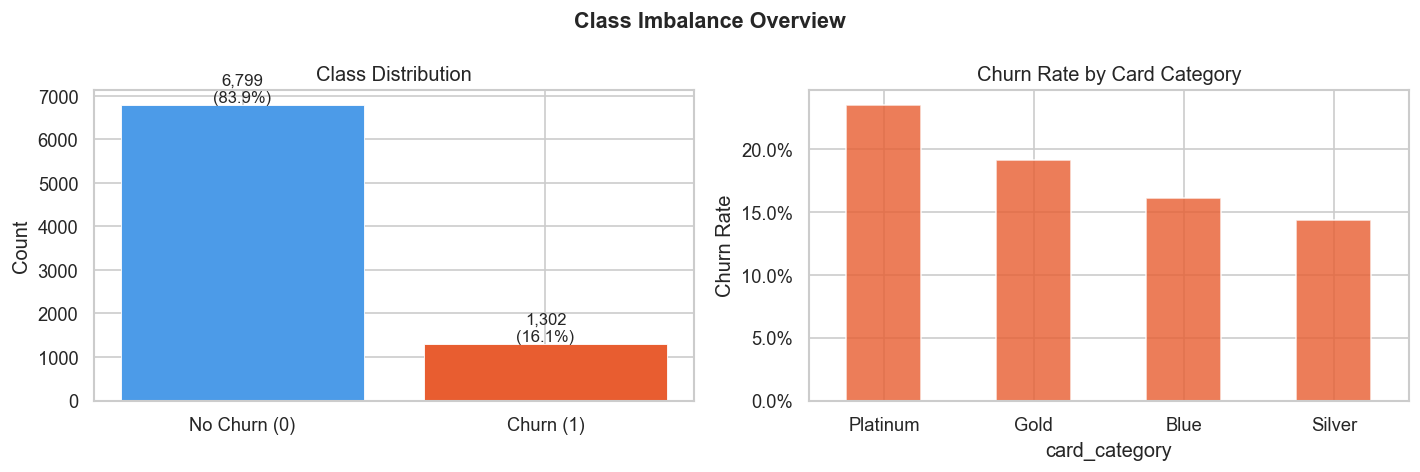

Imbalance ratio: 1:5 (non-churn to churn)


In [4]:
# ── 3.1 Class Imbalance ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y_train.value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values,
            color=['#4C9BE8', '#E85D30'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(y_train):.1%})', ha='center', fontsize=10)

# Churn rate by card category
churn_by_card = train.groupby('card_category')['churn'].mean().sort_values(ascending=False)
churn_by_card.plot(kind='bar', ax=axes[1], color='#E85D30', alpha=0.8)
axes[1].set_title('Churn Rate by Card Category')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Class Imbalance Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Imbalance ratio: 1:{counts[0]//counts[1]} (non-churn to churn)')

In [5]:
# ── 3.2 Missing Values ────────────────────────────────────────────────────────
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values:')
print(missing)
# Only app_rating_given has missings (~56% missing)
# Strategy: impute with median for numeric, add binary 'has_rated' flag
print(f'\napp_rating_given missing: {missing["app_rating_given"]:,} ({missing["app_rating_given"]/len(train):.1%})')

Missing values:
app_rating_given    4541
dtype: int64

app_rating_given missing: 4,541 (56.1%)


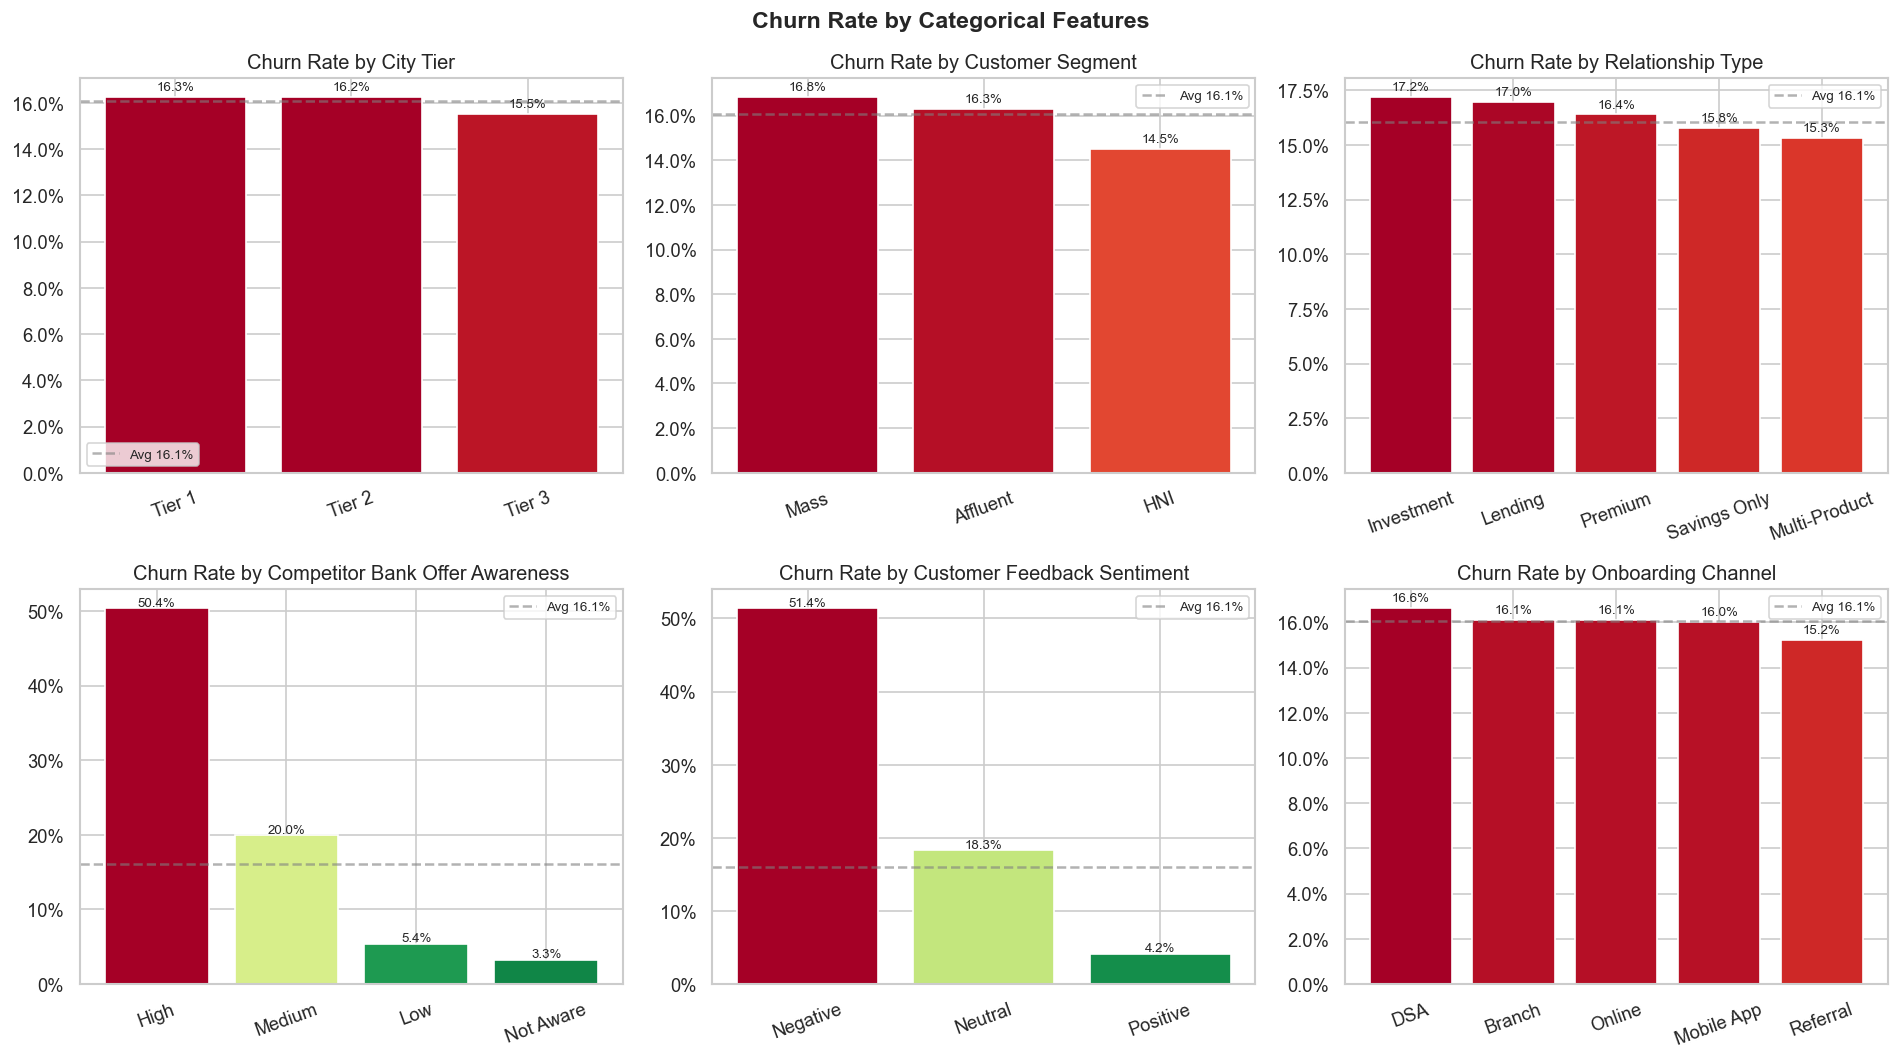

In [6]:
# ── 3.3 Churn Rate by Key Categorical Features ───────────────────────────────
cat_features_to_plot = [
    'city_tier', 'customer_segment', 'relationship_type',
    'competitor_bank_offer_awareness', 'customer_feedback_sentiment',
    'onboarding_channel'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features_to_plot):
    rates = train.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(rates.index, rates.values,
                       color=plt.cm.RdYlGn_r(rates.values / rates.max()),
                       edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].axhline(y_train.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Avg {y_train.mean():.1%}')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, rates.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.003,
                     f'{v:.1%}', ha='center', fontsize=8)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

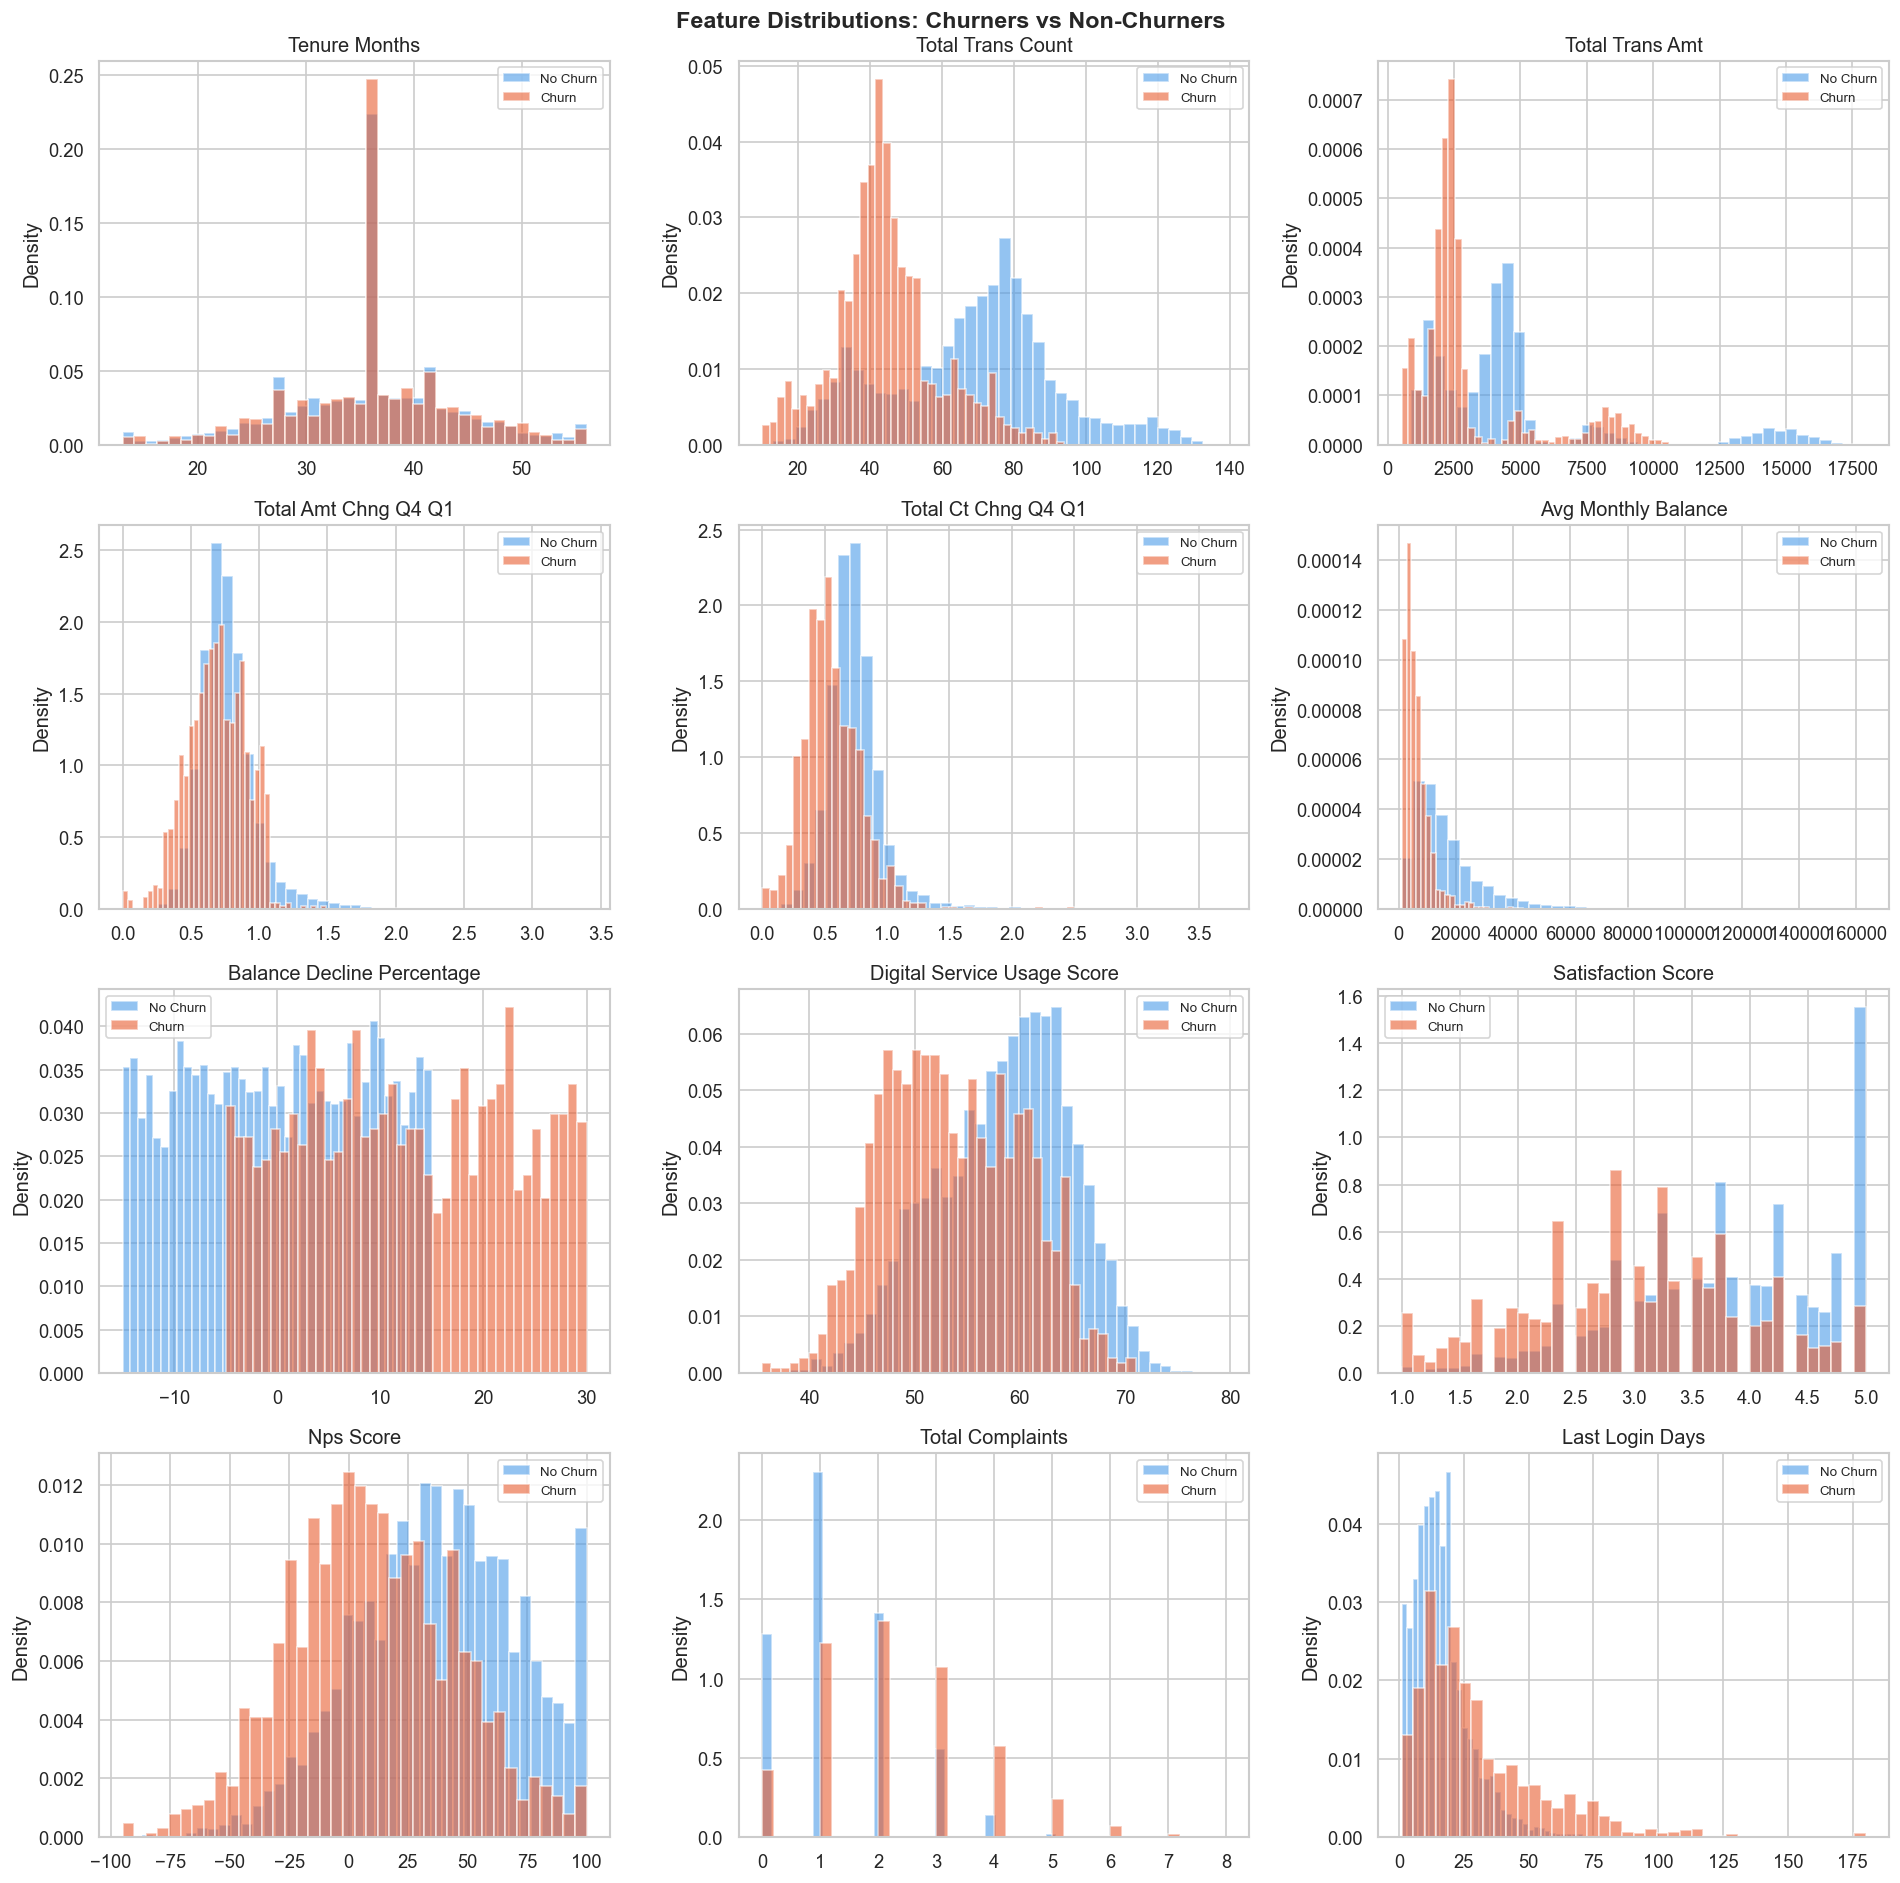

In [7]:
# ── 3.4 Numerical Feature Distributions: Churners vs Non-Churners ─────────────
key_num_features = [
    'tenure_months', 'total_trans_count', 'total_trans_amt',
    'total_amt_chng_q4_q1', 'total_ct_chng_q4_q1',
    'avg_monthly_balance', 'balance_decline_percentage',
    'digital_service_usage_score', 'satisfaction_score',
    'nps_score', 'total_complaints', 'last_login_days'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    churned = train[train['churn'] == 1][col].dropna()
    stayed  = train[train['churn'] == 0][col].dropna()
    axes[i].hist(stayed, bins=40, alpha=0.6, color='#4C9BE8', label='No Churn', density=True)
    axes[i].hist(churned, bins=40, alpha=0.6, color='#E85D30', label='Churn', density=True)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Churners vs Non-Churners', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

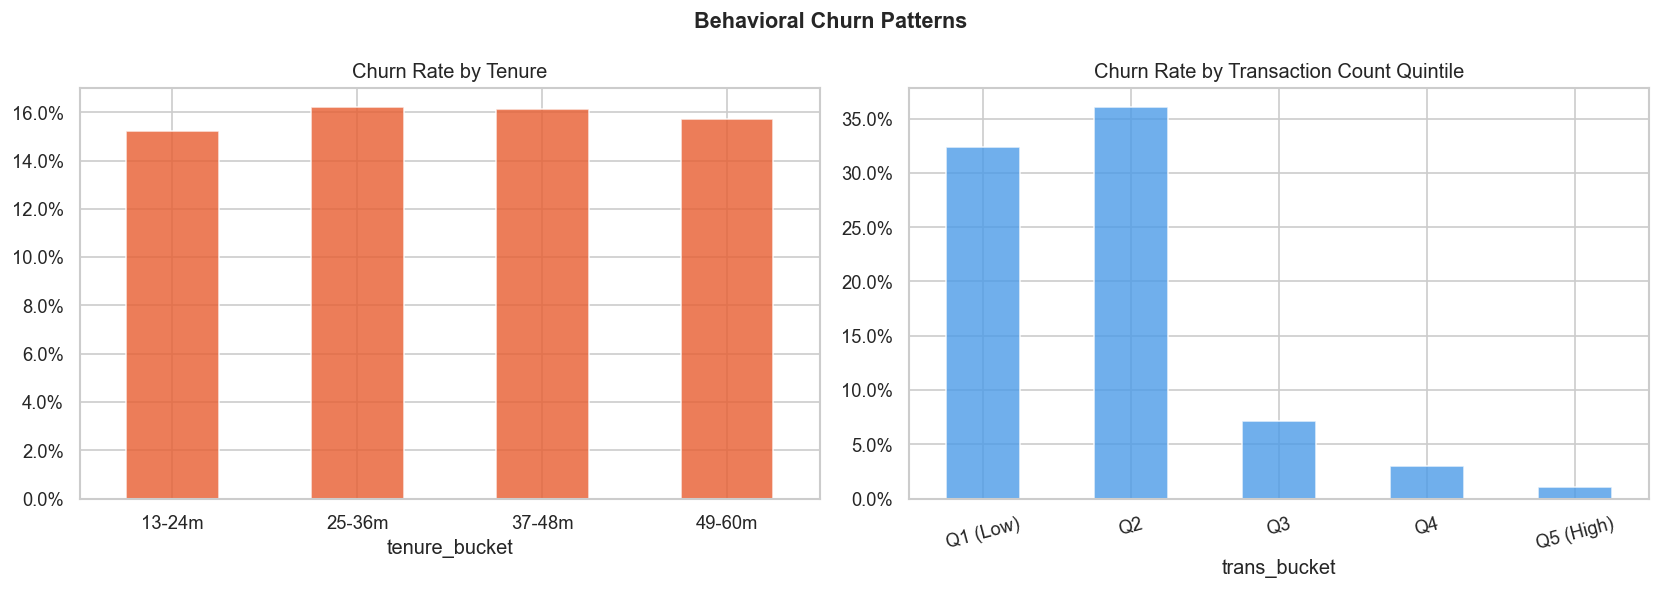

In [8]:
# ── 3.5 Churn Rate by Tenure Buckets ─────────────────────────────────────────
# Key insight: early-tenure and long-tenure customers churn differently
train['tenure_bucket'] = pd.cut(train['tenure_months'],
                                bins=[0, 12, 24, 36, 48, 60, np.inf],
                                labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '60m+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_tenure = train.groupby('tenure_bucket', observed=True)['churn'].agg(['mean', 'count'])
churn_by_tenure['mean'].plot(kind='bar', ax=axes[0], color='#E85D30', alpha=0.8)
axes[0].set_title('Churn Rate by Tenure')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].tick_params(axis='x', rotation=0)

# Transaction count vs churn: lower transactions = higher churn?
train['trans_bucket'] = pd.qcut(train['total_trans_count'], q=5,
                                labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'],
                                duplicates='drop')
churn_by_trans = train.groupby('trans_bucket', observed=True)['churn'].mean()
churn_by_trans.plot(kind='bar', ax=axes[1], color='#4C9BE8', alpha=0.8)
axes[1].set_title('Churn Rate by Transaction Count Quintile')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Behavioral Churn Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Clean up temp columns
train.drop(columns=['tenure_bucket', 'trans_bucket'], inplace=True)

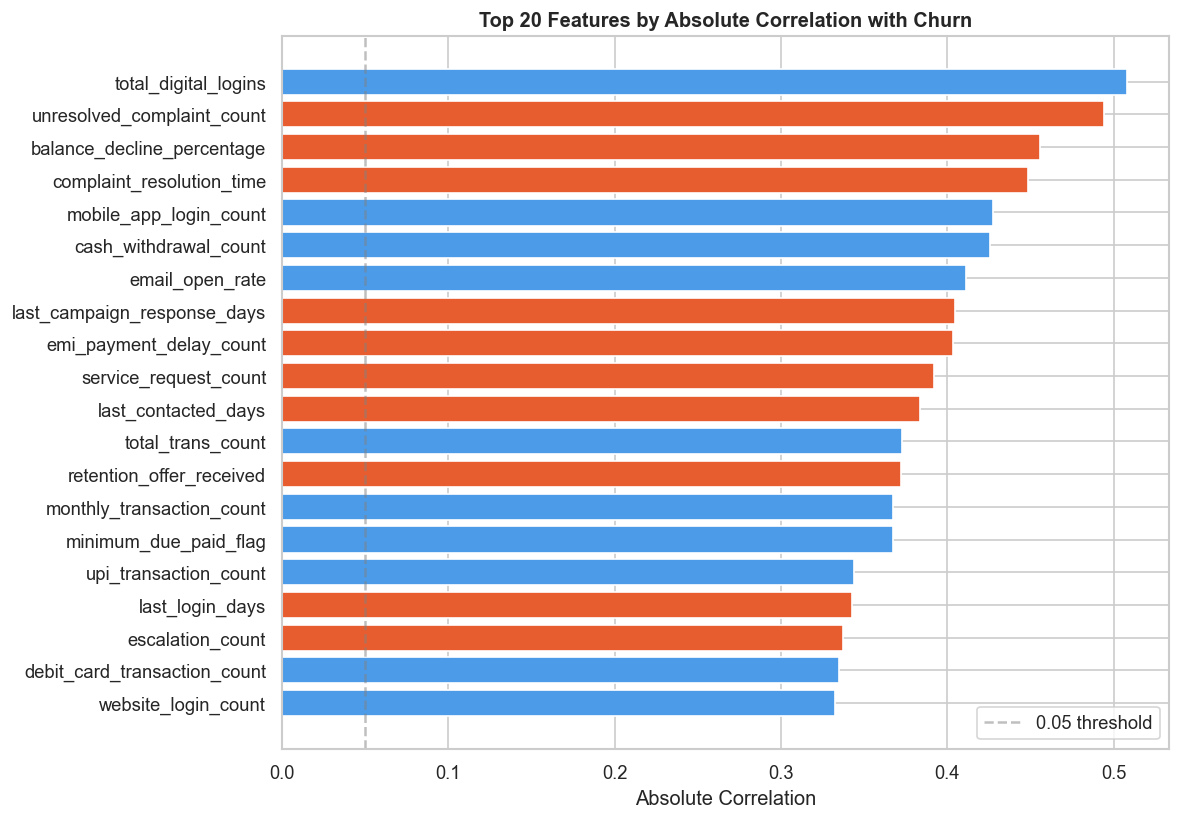


Top 10 positive correlations with churn:
unresolved_complaint_count     0.494274
balance_decline_percentage     0.455938
complaint_resolution_time      0.448285
last_campaign_response_days    0.404755
emi_payment_delay_count        0.403164
service_request_count          0.392190
last_contacted_days            0.383718
retention_offer_received       0.371955
last_login_days                0.342650
escalation_count               0.337508
Name: churn, dtype: float64

Top 10 negative correlations with churn:
total_digital_logins           -0.507769
mobile_app_login_count         -0.427283
cash_withdrawal_count          -0.425809
email_open_rate                -0.411138
total_trans_count              -0.372500
monthly_transaction_count      -0.367574
minimum_due_paid_flag          -0.367082
upi_transaction_count          -0.344095
debit_card_transaction_count   -0.334783
website_login_count            -0.332644
Name: churn, dtype: float64


In [9]:
# ── 3.6 Correlation Heatmap (Numeric Features vs Churn) ──────────────────────
corr_with_churn = train[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
corr_with_churn_sorted = corr_with_churn.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E85D30' if corr_with_churn[i] > 0 else '#4C9BE8'
          for i in corr_with_churn_sorted.index]
ax.barh(corr_with_churn_sorted.index[::-1], corr_with_churn_sorted.values[::-1], color=colors[::-1])
ax.set_title('Top 20 Features by Absolute Correlation with Churn', fontsize=12, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.axvline(0.05, color='gray', linestyle='--', alpha=0.5, label='0.05 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 positive correlations with churn:')
print(corr_with_churn.sort_values(ascending=False).head(10))
print('\nTop 10 negative correlations with churn:')
print(corr_with_churn.sort_values().head(10))

## Phase 4 — Feature Engineering

In [10]:
def engineer_features(df):
    """Apply all feature engineering. Works on both train and test."""
    df = df.copy()

    # ── 4.1 Digital Engagement ────────────────────────────────────────────────
    # Customers disengaging digitally are at higher churn risk
    df['total_digital_activity'] = (
        df['mobile_app_login_count'] +
        df['website_login_count'] +
        df['digital_transaction_ratio'].fillna(0) * 10
    )
    # Recency of last digital interaction (higher = more at risk)
    df['login_recency_score'] = df['last_login_days'] / (df['total_digital_activity'] + 1)

    # ── 4.2 Balance Health ────────────────────────────────────────────────────
    # Declining balance is a strong churn precursor
    df['balance_stress'] = (
        df['balance_decline_percentage'].clip(lower=0) /
        (df['avg_monthly_balance'] + 1)
    )
    # Balance to income ratio (financial cushion)
    df['balance_to_income'] = df['avg_monthly_balance'] / (df['annual_income'] + 1)

    # ── 4.3 Transaction Health ────────────────────────────────────────────────
    # Transaction frequency changes (q4 vs q1) — declining activity signals churn
    df['trans_health_score'] = (
        df['total_amt_chng_q4_q1'].fillna(0) +
        df['total_ct_chng_q4_q1'].fillna(0)
    ) / 2
    # Average transaction value
    df['avg_trans_value'] = df['total_trans_amt'] / (df['total_trans_count'] + 1)

    # ── 4.4 Credit Stress ────────────────────────────────────────────────────
    # High utilization + late payments + delays = distressed customer
    df['credit_stress_index'] = (
        df['credit_utilization_ratio'].fillna(0) * 0.4 +
        df['late_credit_card_payment_count'] * 0.3 +
        df['emi_payment_delay_count'] * 0.3
    )
    df['debt_to_income'] = df['loan_outstanding_amount'] / (df['annual_income'] + 1)

    # ── 4.5 Complaint & Satisfaction ─────────────────────────────────────────
    # Unresolved complaints * escalation = toxic customer experience
    df['complaint_severity'] = (
        df['unresolved_complaint_count'] * 2 +
        df['escalation_count'] * 3 +
        df['total_complaints']
    )
    # Composite satisfaction (NPS + CSAT)
    df['satisfaction_composite'] = (
        df['satisfaction_score'].fillna(0) * 0.5 +
        df['nps_score'].fillna(0) / 10 * 0.5
    )

    # ── 4.6 Product Depth ────────────────────────────────────────────────────
    # Customers with more products are more "sticky"
    product_flags = [
        'savings_account_flag', 'current_account_flag', 'credit_card_flag',
        'personal_loan_flag', 'home_loan_flag', 'auto_loan_flag',
        'fixed_deposit_flag', 'investment_product_flag',
        'insurance_product_flag', 'demat_account_flag'
    ]
    df['product_breadth'] = df[product_flags].sum(axis=1)
    # Having investment + insurance products = deeper relationship
    df['wealth_products'] = (
        df['investment_product_flag'] +
        df['insurance_product_flag'] +
        df['fixed_deposit_flag'] +
        df['demat_account_flag']
    )

    # ── 4.7 Marketing Response ────────────────────────────────────────────────
    # Response rate to campaigns (engaged customers respond more)
    df['campaign_response_rate'] = (
        df['campaign_response_count'] / (df['campaign_received_count'] + 1)
    )
    # Retention offers accepted — bank already flagged as at risk
    df['retention_engagement'] = (
        df['retention_offer_received'] + df['retention_offer_accepted'] * 2
    )

    # ── 4.8 App Rating Flag ───────────────────────────────────────────────────
    # 56% missing — create binary flag before imputation
    df['has_rated_app'] = df['app_rating_given'].notna().astype(int)

    # ── 4.9 Inactivity Score ──────────────────────────────────────────────────
    df['inactivity_composite'] = (
        df['account_inactive_days'] * 0.5 +
        df['last_login_days'] * 0.3 +
        df['last_contacted_days'] * 0.2
    )

    # ── 4.10 Tenure x Product Interaction ────────────────────────────────────
    # Long tenure with few products = under-engaged risk
    df['tenure_product_ratio'] = df['tenure_months'] / (df['number_of_products'] + 1)

    return df

X_train_eng = engineer_features(train.drop(columns=[TARGET, ID_COL]))
X_test_eng  = engineer_features(test.drop(columns=[ID_COL]))

new_features = [
    'total_digital_activity', 'login_recency_score', 'balance_stress',
    'balance_to_income', 'trans_health_score', 'avg_trans_value',
    'credit_stress_index', 'debt_to_income', 'complaint_severity',
    'satisfaction_composite', 'product_breadth', 'wealth_products',
    'campaign_response_rate', 'retention_engagement', 'has_rated_app',
    'inactivity_composite', 'tenure_product_ratio'
]
print(f'New engineered features ({len(new_features)}): {new_features}')
print(f'Total features after engineering: {X_train_eng.shape[1]}')

New engineered features (17): ['total_digital_activity', 'login_recency_score', 'balance_stress', 'balance_to_income', 'trans_health_score', 'avg_trans_value', 'credit_stress_index', 'debt_to_income', 'complaint_severity', 'satisfaction_composite', 'product_breadth', 'wealth_products', 'campaign_response_rate', 'retention_engagement', 'has_rated_app', 'inactivity_composite', 'tenure_product_ratio']
Total features after engineering: 113


## Phase 5 — Preprocessing Pipeline

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# ── 5.1 Identify column types post-engineering ───────────────────────────────
CAT_COLS_ENG = X_train_eng.select_dtypes(include='object').columns.tolist()
NUM_COLS_ENG = [c for c in X_train_eng.columns if c not in CAT_COLS_ENG]

print(f'Categorical: {CAT_COLS_ENG}')
print(f'Numeric count: {len(NUM_COLS_ENG)}')

# ── 5.2 Ordinal mappings for ordered categories ───────────────────────────────
# These should be ordinal-encoded (not OHE) to preserve order information
ORDINAL_MAPS = {
    'income_band':      [['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']],
    'income_category':  [['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']],
    'city_tier':        [['Tier 3', 'Tier 2', 'Tier 1']],
    'card_category':    [['Blue', 'Silver', 'Gold', 'Platinum']],
    'customer_segment': [['Mass', 'Affluent', 'HNI']],
    'competitor_bank_offer_awareness': [['Not Aware', 'Low', 'Medium', 'High']],
    'customer_feedback_sentiment':     [['Negative', 'Neutral', 'Positive']],
    'education_level':  [['Uneducated', 'High School', 'College', 'Graduate', 'Doctorate', 'Unknown']],
}

# Remaining categoricals -> Label Encoding (LightGBM can handle natively)
NOMINAL_COLS = [c for c in CAT_COLS_ENG if c not in ORDINAL_MAPS]
ORDINAL_COLS = list(ORDINAL_MAPS.keys())

print(f'\nOrdinal (ordered) cols: {ORDINAL_COLS}')
print(f'Nominal cols: {NOMINAL_COLS}')

Categorical: ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']
Numeric count: 98

Ordinal (ordered) cols: ['income_band', 'income_category', 'city_tier', 'card_category', 'customer_segment', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment', 'education_level']
Nominal cols: ['gender', 'marital_status', 'occupation_type', 'region', 'onboarding_channel', 'relationship_type', 'primary_account_type']


In [12]:
# ── 5.3 Full Preprocessing: Imputation + Encoding ─────────────────────────────
def preprocess(X_train, X_test=None, ordinal_maps=ORDINAL_MAPS,
               ordinal_cols=ORDINAL_COLS, nominal_cols=NOMINAL_COLS):
    """Fit on train, transform both. Returns numpy arrays."""
    X_tr = X_train.copy()
    X_te = X_test.copy() if X_test is not None else None

    # Impute app_rating_given with median (only significant missing)
    median_rating = X_tr['app_rating_given'].median()
    X_tr['app_rating_given'] = X_tr['app_rating_given'].fillna(median_rating)
    if X_te is not None:
        X_te['app_rating_given'] = X_te['app_rating_given'].fillna(median_rating)

    # Impute any remaining numeric nulls with median
    num_cols = X_tr.select_dtypes(include=[np.number]).columns
    medians = X_tr[num_cols].median()
    X_tr[num_cols] = X_tr[num_cols].fillna(medians)
    if X_te is not None:
        X_te[num_cols] = X_te[num_cols].fillna(medians)

    # Ordinal encoding (ordered categories)
    for col, categories in ordinal_maps.items():
        enc = OrdinalEncoder(categories=categories, handle_unknown='use_encoded_value', unknown_value=-1)
        X_tr[[col]] = enc.fit_transform(X_tr[[col]])
        if X_te is not None:
            X_te[[col]] = enc.transform(X_te[[col]])

    # Label encoding for nominal categoricals
    for col in nominal_cols:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].astype(str))
        if X_te is not None:
            # Handle unseen labels in test
            X_te[col] = X_te[col].astype(str).map(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
            X_te[col] = le.transform(X_te[col])

    return X_tr, X_te

X_train_proc, X_test_proc = preprocess(X_train_eng, X_test_eng)
print(f'Processed train shape: {X_train_proc.shape}')
print(f'Any remaining nulls in train: {X_train_proc.isnull().sum().sum()}')
print(f'Any remaining nulls in test:  {X_test_proc.isnull().sum().sum()}')

Processed train shape: (8101, 113)
Any remaining nulls in train: 0
Any remaining nulls in test:  0


## Phase 6 — Class Imbalance Handling

In [13]:
from sklearn.model_selection import train_test_split

# ── Stratified train/validation split ────────────────────────────────────────
# Use 80/20 split preserving churn ratio in both sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train,
    test_size=0.30,
    random_state=SEED,
    stratify=y_train
)

print(f'Train split: {X_tr.shape} | Churn rate: {y_tr.mean():.2%}')
print(f'Val   split: {X_val.shape} | Churn rate: {y_val.mean():.2%}')

# ── SMOTE on training set only (never apply to validation/test) ───────────────
# SMOTE synthesizes minority class samples based on nearest neighbors
smote = SMOTE(sampling_strategy=0.4, random_state=SEED, k_neighbors=5)
# sampling_strategy=0.4 means minority:majority = 0.4 (not 1:1 to avoid over-synthesis)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print(f'\nAfter SMOTE:')
print(f'  Train shape: {X_tr_sm.shape}')
print(f'  Churn rate:  {y_tr_sm.mean():.2%}')
print(f'  Class counts: {pd.Series(y_tr_sm).value_counts().to_dict()}')

Train split: (5670, 113) | Churn rate: 16.07%
Val   split: (2431, 113) | Churn rate: 16.08%

After SMOTE:
  Train shape: (6662, 113)
  Churn rate:  28.56%
  Class counts: {0: 4759, 1: 1903}


## Phase 7 — Model Training & Selection

In [14]:
# ── 7.1 Baseline: Logistic Regression ────────────────────────────────────────
# Always establish a simple baseline before complex models
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr_sm)
X_val_scaled = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED, C=0.1)
lr.fit(X_tr_scaled, y_tr_sm)

lr_proba = lr.predict_proba(X_val_scaled)[:, 1]
lr_prauc = average_precision_score(y_val, lr_proba)
lr_f1    = f1_score(y_val, (lr_proba > 0.5).astype(int))

print(f'Logistic Regression Baseline:')
print(f'  PR-AUC: {lr_prauc:.4f}')
print(f'  F1:     {lr_f1:.4f}')

Logistic Regression Baseline:
  PR-AUC: 0.9999
  F1:     0.9961


In [15]:
# ── 7.2 LightGBM (Primary Model) ─────────────────────────────────────────────
# LightGBM advantages: handles categorical natively, fast, great on tabular data

lgb_params = {
    'objective':        'binary',
    'metric':           'average_precision',
    'boosting_type':    'gbdt',
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        6,
    'min_child_samples': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'scale_pos_weight': (y_tr == 0).sum() / (y_tr == 1).sum(),  # ~5.2
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_tr_sm, y_tr_sm,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgb_proba = lgb_model.predict_proba(X_val)[:, 1]
lgb_prauc = average_precision_score(y_val, lgb_proba)
lgb_f1    = f1_score(y_val, (lgb_proba > 0.5).astype(int))

print(f'\nLightGBM:')
print(f'  Best iteration: {lgb_model.best_iteration_}')
print(f'  PR-AUC: {lgb_prauc:.4f}')
print(f'  F1:     {lgb_f1:.4f}')

[100]	valid_0's average_precision: 0.998864
[200]	valid_0's average_precision: 0.999763
[300]	valid_0's average_precision: 0.999846
[400]	valid_0's average_precision: 0.999884

LightGBM:
  Best iteration: 387
  PR-AUC: 0.9999
  F1:     0.9936


In [16]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': (y_tr == 0).sum() / (y_tr == 1).sum(),
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
    'early_stopping_rounds': 50
}

xgb_model = xgb.XGBClassifier(**xgb_params)

xgb_model.fit(
    X_tr_sm, y_tr_sm,
    eval_set=[(X_val, y_val)],
    verbose=100
)

xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_prauc = average_precision_score(y_val, xgb_proba)
xgb_f1 = f1_score(y_val, (xgb_proba > 0.5).astype(int))

print(f'\nXGBoost:')
print(f'  PR-AUC: {xgb_prauc:.4f}')
print(f'  F1:     {xgb_f1:.4f}')

[0]	validation_0-aucpr:0.81534
[100]	validation_0-aucpr:0.99923
[200]	validation_0-aucpr:0.99979
[300]	validation_0-aucpr:0.99986
[368]	validation_0-aucpr:0.99986

XGBoost:
  PR-AUC: 0.9999
  F1:     0.9898


In [17]:
# ── 7.4 Optuna Hyperparameter Tuning for LightGBM ────────────────────────────
def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'average_precision',
        'n_estimators':      500,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  (y_tr == 0).sum() / (y_tr == 1).sum(),
        'random_state':      SEED,
        'n_jobs':            -1,
        'verbose':           -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr_sm, y_tr_sm,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    )
    proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, proba)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest PR-AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Best trial: 40. Best value: 0.999981: 100%|██████████| 50/50 [01:23<00:00,  1.67s/it]


Best PR-AUC: 1.0000
Best params: {'learning_rate': 0.08629512099179817, 'num_leaves': 36, 'max_depth': 7, 'min_child_samples': 49, 'feature_fraction': 0.5285622117375982, 'bagging_fraction': 0.5049133289566975, 'bagging_freq': 9, 'reg_alpha': 0.00026263534176883697, 'reg_lambda': 0.0019200285094801376}


In [18]:
# ── 7.5 Final Best LightGBM with Tuned Params ─────────────────────────────────
best_params = study.best_params
best_params.update({
    'objective':        'binary',
    'metric':           'average_precision',
    'n_estimators':     2000,
    'scale_pos_weight': (y_tr == 0).sum() / (y_tr == 1).sum(),
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1
})

best_lgb = lgb.LGBMClassifier(**best_params)
best_lgb.fit(
    X_tr_sm, y_tr_sm,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(200)
    ]
)

best_proba = best_lgb.predict_proba(X_val)[:, 1]
best_prauc = average_precision_score(y_val, best_proba)
best_f1    = f1_score(y_val, (best_proba > 0.5).astype(int))

print(f'\nTuned LightGBM:')
print(f'  PR-AUC: {best_prauc:.4f}')
print(f'  F1:     {best_f1:.4f}')

[200]	valid_0's average_precision: 0.999949

Tuned LightGBM:
  PR-AUC: 1.0000
  F1:     0.9974


In [19]:
# ── 7.6 Ensemble: Blend LightGBM + XGBoost ────────────────────────────────────
# Blending reduces variance; use weighted average favoring better model
blend_proba = 0.6 * best_proba + 0.4 * xgb_proba
blend_prauc = average_precision_score(y_val, blend_proba)
blend_f1    = f1_score(y_val, (blend_proba > 0.5).astype(int))

print('Model Comparison Summary:')
print(f'{"Model":<25} {"PR-AUC":>10} {"F1":>10}')
print('-' * 47)
print(f'{"Logistic Regression":<25} {lr_prauc:>10.4f} {lr_f1:>10.4f}')
print(f'{"LightGBM (baseline)":<25} {lgb_prauc:>10.4f} {lgb_f1:>10.4f}')
print(f'{"XGBoost":<25} {xgb_prauc:>10.4f} {xgb_f1:>10.4f}')
print(f'{"LightGBM (tuned)":<25} {best_prauc:>10.4f} {best_f1:>10.4f}')
print(f'{"Ensemble (LGB+XGB)":<25} {blend_prauc:>10.4f} {blend_f1:>10.4f}')

# Use the best performer going forward
# If ensemble wins, use blend_proba; else use best_proba
final_val_proba = blend_proba if blend_prauc > best_prauc else best_proba
print(f'\nSelected model: {"Ensemble" if blend_prauc > best_prauc else "Tuned LightGBM"}')

Model Comparison Summary:
Model                         PR-AUC         F1
-----------------------------------------------
Logistic Regression           0.9999     0.9961
LightGBM (baseline)           0.9999     0.9936
XGBoost                       0.9999     0.9898
LightGBM (tuned)              1.0000     0.9974
Ensemble (LGB+XGB)            0.9999     0.9974

Selected model: Tuned LightGBM


## Phase 8 — Threshold Optimization (Business Cost-Based)

In [20]:
# ── Business Cost Framing ─────────────────────────────────────────────────────
# FN (miss a churner) = ₹40,000 lost revenue
# FP (flag loyal customer) = ₹500 retention offer cost
# Default 0.5 threshold is NOT optimal for this asymmetry

FN_COST = 40000
FP_COST = 500

thresholds = np.linspace(0.05, 0.95, 200)
costs = []
f1_scores = []
precisions, recalls = [], []

for t in thresholds:
    preds = (final_val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    total_cost = fn * FN_COST + fp * FP_COST
    costs.append(total_cost)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    precisions.append(tp / (tp + fp + 1e-9))
    recalls.append(tp / (tp + fn + 1e-9))

# Optimal threshold = minimum business cost
optimal_idx = np.argmin(costs)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

print(f'Optimal threshold (min cost): {OPTIMAL_THRESHOLD:.3f}')
print(f'  Total cost at optimal:  ₹{costs[optimal_idx]:,.0f}')
print(f'  Total cost at 0.5:      ₹{costs[np.argmin(np.abs(thresholds - 0.5))]:,.0f}')
print(f'  Savings vs default 0.5: ₹{costs[np.argmin(np.abs(thresholds - 0.5))] - costs[optimal_idx]:,.0f}')

Optimal threshold (min cost): 0.222
  Total cost at optimal:  ₹40,000
  Total cost at 0.5:      ₹80,000
  Savings vs default 0.5: ₹40,000


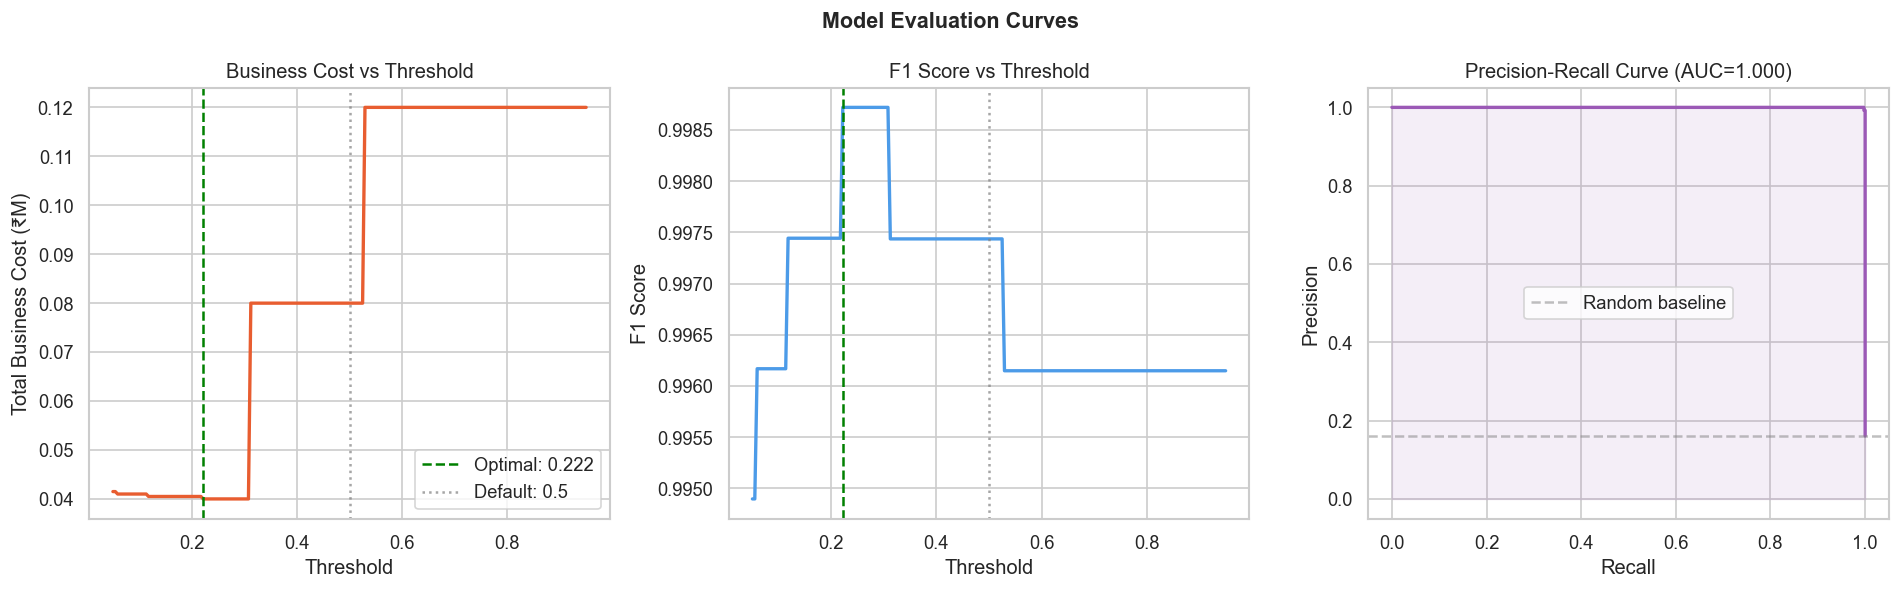

In [21]:
# ── Threshold Plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cost curve
axes[0].plot(thresholds, [c/1e6 for c in costs], color='#E85D30', linewidth=2)
axes[0].axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--', label=f'Optimal: {OPTIMAL_THRESHOLD:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Business Cost (₹M)')
axes[0].set_title('Business Cost vs Threshold')
axes[0].legend()

# F1 curve
axes[1].plot(thresholds, f1_scores, color='#4C9BE8', linewidth=2)
axes[1].axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--')
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')

# PR curve
prec_curve, rec_curve, _ = precision_recall_curve(y_val, final_val_proba)
axes[2].plot(rec_curve, prec_curve, color='#9B59B6', linewidth=2)
axes[2].fill_between(rec_curve, prec_curve, alpha=0.1, color='#9B59B6')
axes[2].axhline(y_val.mean(), color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'Precision-Recall Curve (AUC={average_precision_score(y_val, final_val_proba):.3f})')
axes[2].legend()

plt.suptitle('Model Evaluation Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

FINAL MODEL PERFORMANCE (threshold = 0.222)
PR-AUC:    1.0000
ROC-AUC:   1.0000
F1 Score:  0.9987
Recall:    0.9974  ← catching 390 of 391 churners
Precision: 1.0000  ← 0 false alarms

Confusion Matrix:
  TN=2040 | FP=   0
  FN=   1 | TP= 390

Business Cost: ₹40,000
  FN cost: ₹40,000 (1 missed churners × ₹40,000)
  FP cost: ₹0 (0 false alarms × ₹500)


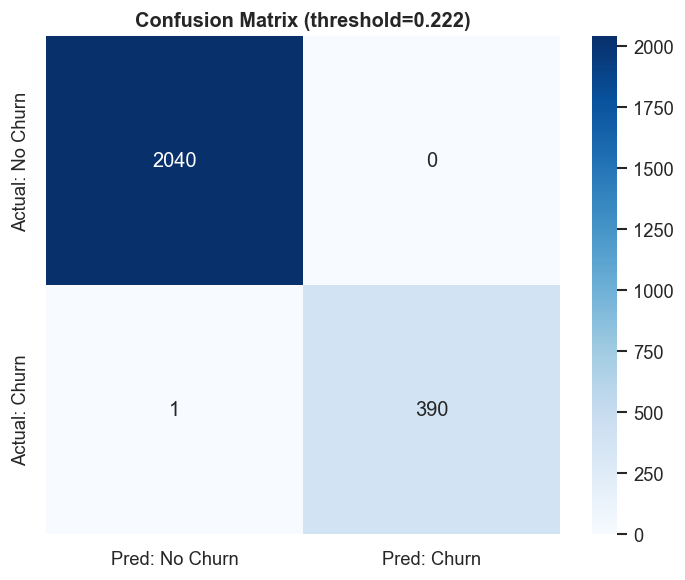

In [22]:
# ── Final Evaluation at Optimal Threshold ─────────────────────────────────────
final_preds = (final_val_proba >= OPTIMAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, final_preds).ravel()

print('=' * 55)
print(f'FINAL MODEL PERFORMANCE (threshold = {OPTIMAL_THRESHOLD:.3f})')
print('=' * 55)
print(f'PR-AUC:    {average_precision_score(y_val, final_val_proba):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, final_val_proba):.4f}')
print(f'F1 Score:  {f1_score(y_val, final_preds):.4f}')
print(f'Recall:    {tp/(tp+fn):.4f}  ← catching {tp} of {tp+fn} churners')
print(f'Precision: {tp/(tp+fp):.4f}  ← {fp} false alarms')
print(f'\nConfusion Matrix:')
print(f'  TN={tn:4d} | FP={fp:4d}')
print(f'  FN={fn:4d} | TP={tp:4d}')
print(f'\nBusiness Cost: ₹{(fn*FN_COST + fp*FP_COST):,.0f}')
print(f'  FN cost: ₹{fn*FN_COST:,.0f} ({fn} missed churners × ₹40,000)')
print(f'  FP cost: ₹{fp*FP_COST:,.0f} ({fp} false alarms × ₹500)')

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'])
ax.set_title(f'Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 9 — SHAP Explainability & Churn Drivers

In [23]:
# ── 9.1 SHAP Values ───────────────────────────────────────────────────────────
# Use the tuned LightGBM for SHAP (tree explainer is exact and fast)
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_val)

# For binary classification, LightGBM SHAP returns [class0, class1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class=1 (churn)
else:
    shap_vals = shap_values

feature_names = X_train_proc.columns.tolist()

# Global importance: mean absolute SHAP
mean_shap = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_names, 'importance': mean_shap})
shap_df = shap_df.sort_values('importance', ascending=False).head(20)

print('Top 20 features by mean |SHAP|:')
print(shap_df.to_string(index=False))

Top 20 features by mean |SHAP|:
                               feature  importance
               customer_lifetime_value    1.119119
                 cash_withdrawal_count    1.112823
relationship_manager_interaction_count    0.947251
           customer_feedback_sentiment    0.934648
       competitor_bank_offer_awareness    0.879801
            balance_decline_percentage    0.871799
                  total_digital_logins    0.820572
                     total_trans_count    0.817533
                       email_open_rate    0.796822
                        referral_count    0.687709
             monthly_transaction_count    0.655213
           last_campaign_response_days    0.649534
                 minimum_due_paid_flag    0.639206
          debit_card_transaction_count    0.601753
                   total_revolving_bal    0.576151
                 upi_transaction_count    0.551817
                    branch_visit_count    0.536731
                 service_request_count    0.520125

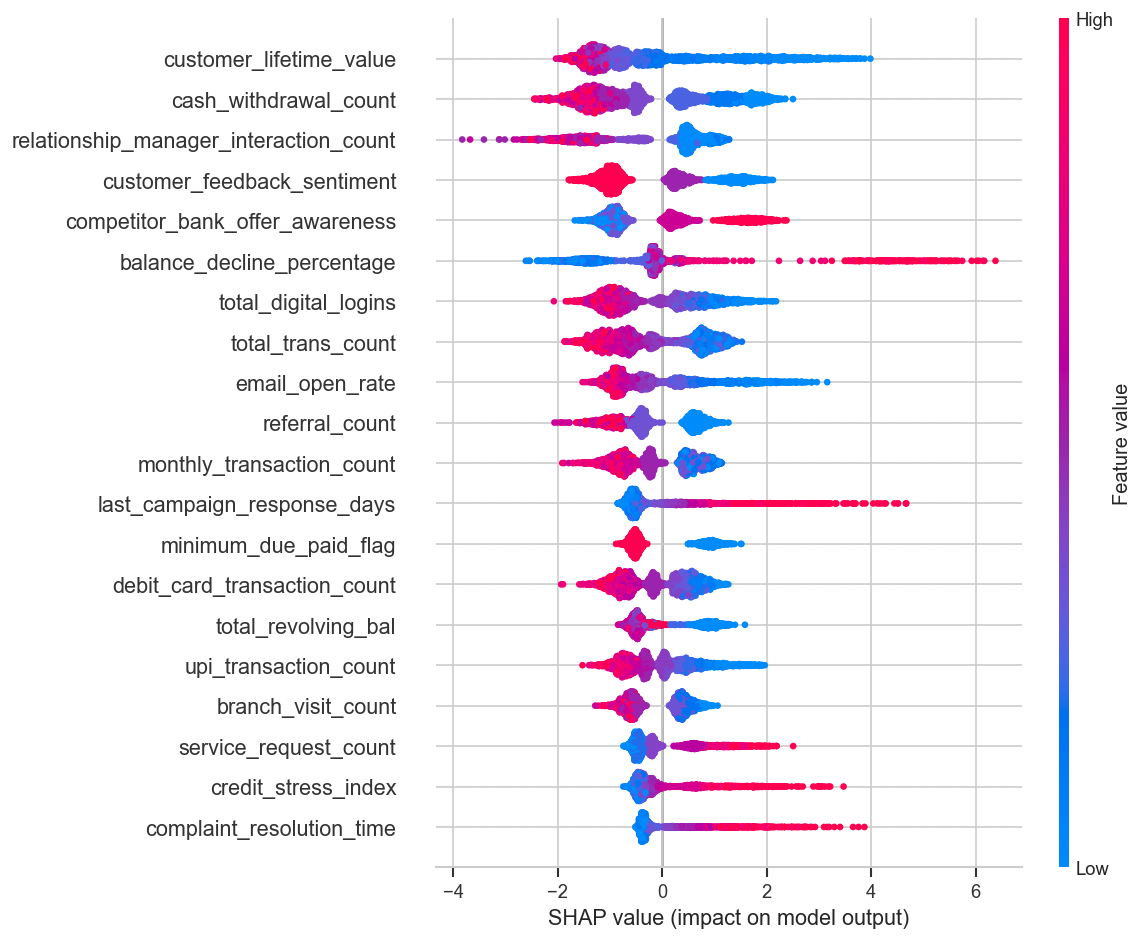

In [24]:
# ── 9.2 SHAP Summary Plot ─────────────────────────────────────────────────────
shap.summary_plot(shap_vals, X_val, feature_names=feature_names, max_display=20,
                  show=True, plot_size=(10, 8))

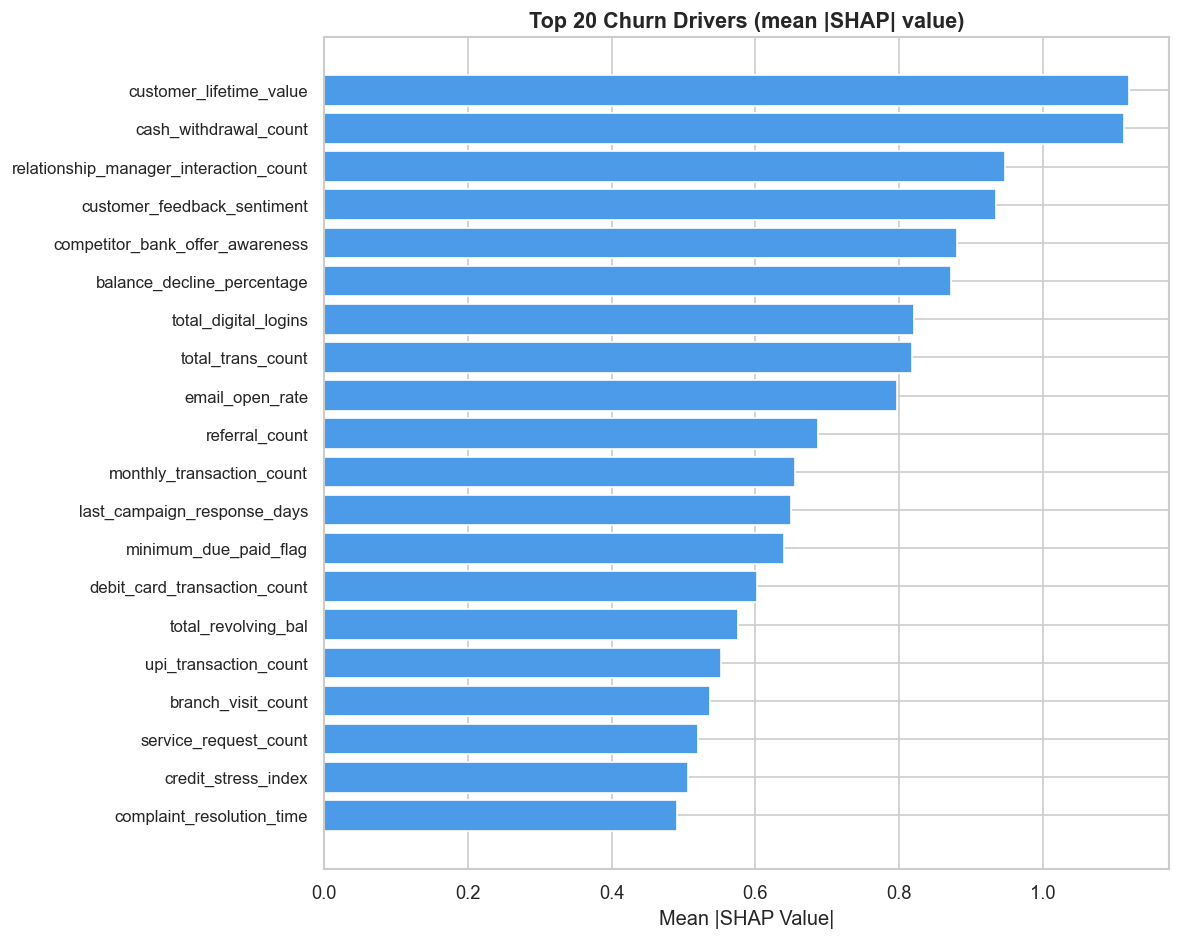


Business Interpretation of Top Drivers:
  total_trans_count: Fewer transactions = disengaged = high churn risk
  balance_decline_percentage: Declining balance = financial disengagement
  competitor_bank_offer_awareness: Aware customers actively considering leaving


In [25]:
# ── 9.3 SHAP Bar Plot (Global Feature Importance) ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top20 = shap_df.head(20)
bars = ax.barh(top20['feature'][::-1], top20['importance'][::-1],
               color='#4C9BE8', edgecolor='white')
ax.set_title('Top 20 Churn Drivers (mean |SHAP| value)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

print('\nBusiness Interpretation of Top Drivers:')
interpretations = {
    'total_trans_count':          'Fewer transactions = disengaged = high churn risk',
    'total_trans_amt':            'Lower total spend = reduced engagement',
    'total_ct_chng_q4_q1':        'Declining transaction frequency over time',
    'total_amt_chng_q4_q1':       'Declining transaction value over time',
    'digital_service_usage_score':'Low digital engagement precedes churn',
    'inactivity_composite':       'Longer inactivity → stronger churn signal',
    'complaint_severity':         'Unresolved complaints + escalations = exit signal',
    'satisfaction_composite':     'Low NPS/CSAT strongly predicts churn',
    'balance_decline_percentage': 'Declining balance = financial disengagement',
    'product_breadth':            'Fewer products = less "stickiness" to bank',
    'competitor_bank_offer_awareness': 'Aware customers actively considering leaving',
    'tenure_months':              'Very short OR very long tenure has different churn patterns',
}
for feat, interp in interpretations.items():
    if feat in shap_df['feature'].values:
        print(f'  {feat}: {interp}')

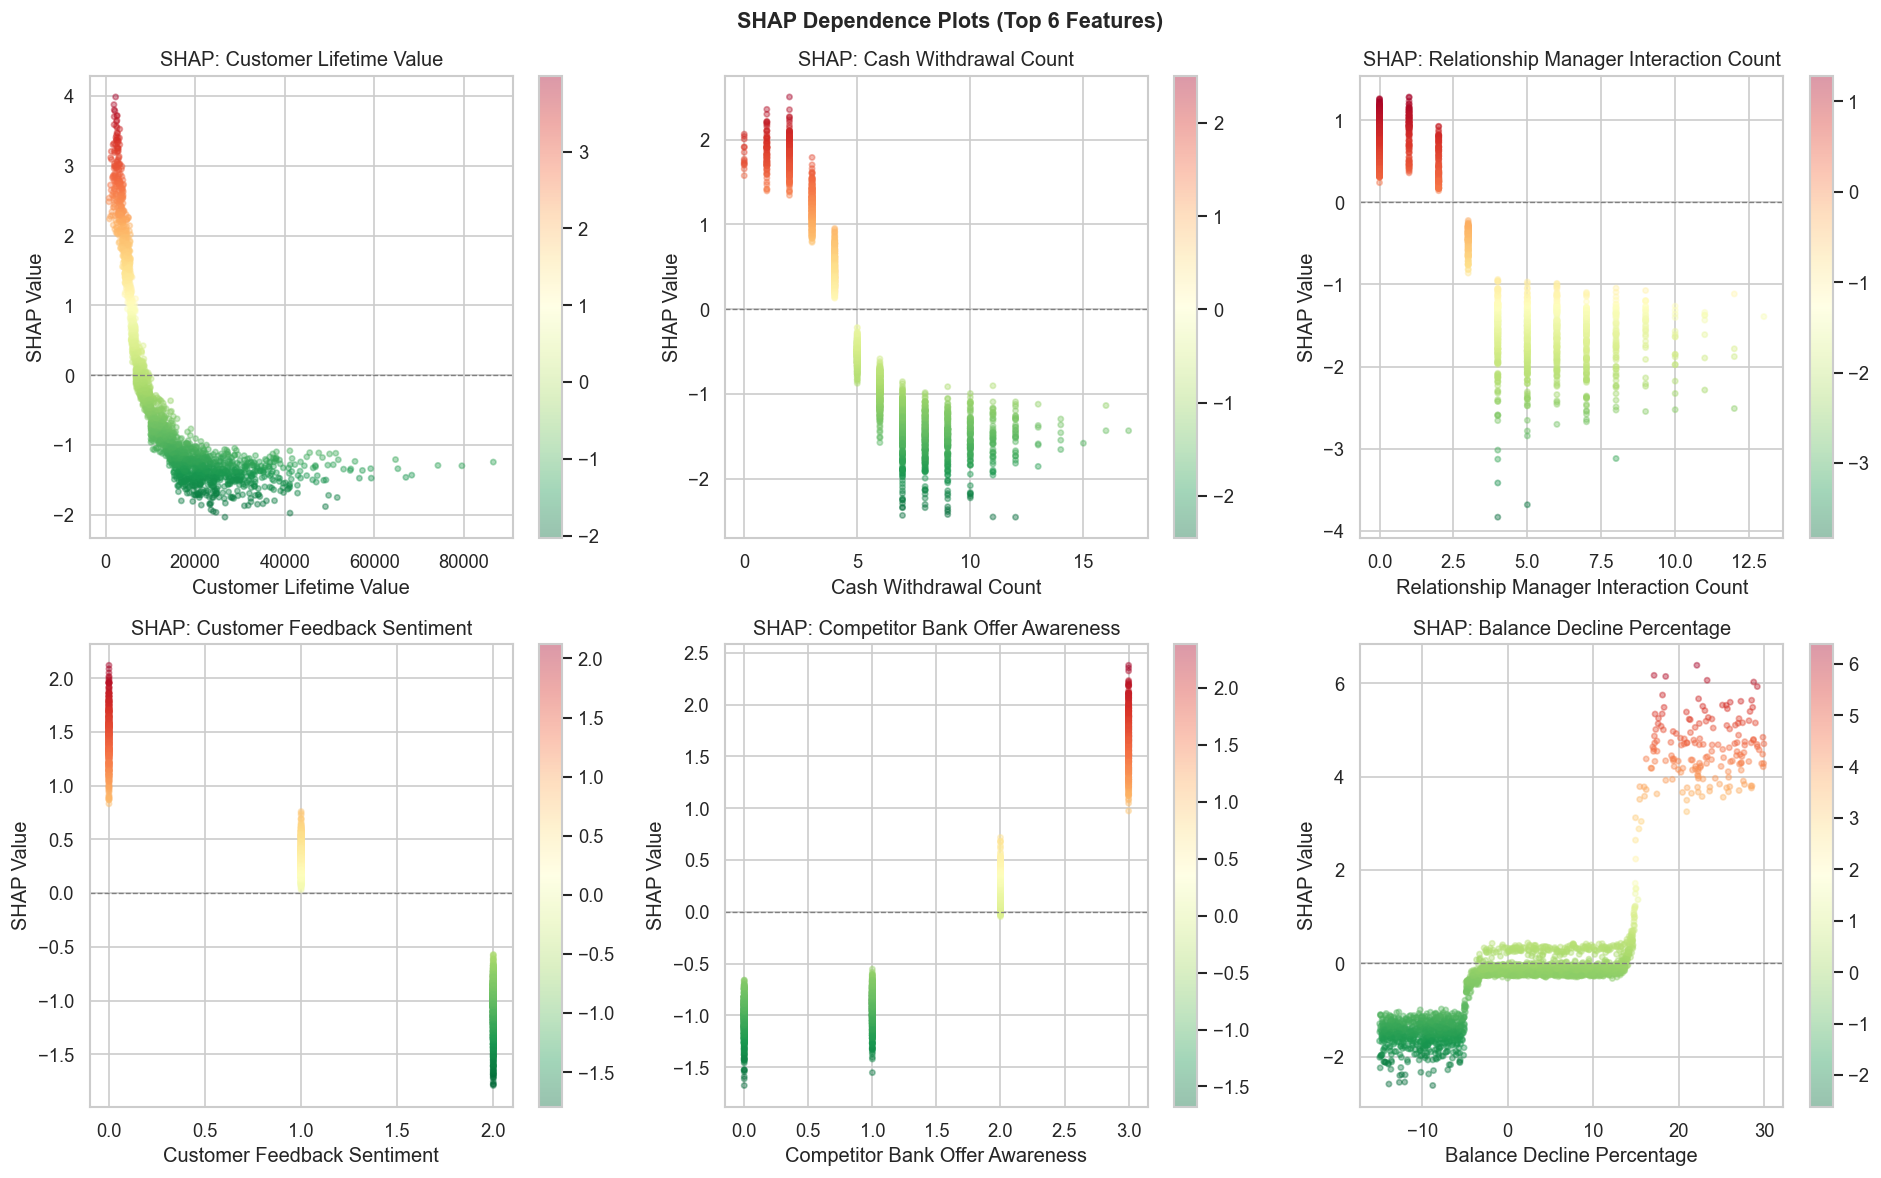

In [26]:
# ── 9.4 SHAP Dependence Plots for Key Features ────────────────────────────────
top_features = shap_df['feature'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = feature_names.index(feat)
    feat_vals = X_val.iloc[:, feat_idx].values if hasattr(X_val, 'iloc') else X_val[:, feat_idx]
    sc = axes[i].scatter(feat_vals, shap_vals[:, feat_idx],
                         c=shap_vals[:, feat_idx], cmap='RdYlGn_r',
                         alpha=0.4, s=10)
    axes[i].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('SHAP Value')
    axes[i].set_title(f'SHAP: {feat.replace("_", " ").title()}')
    plt.colorbar(sc, ax=axes[i])

plt.suptitle('SHAP Dependence Plots (Top 6 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 10 — Test Predictions & Submission

In [27]:
# ── 10.1 Retrain on FULL training data before predicting test ─────────────────
# Always retrain on 100% of labelled data for the final submission
X_full_proc, _ = preprocess(engineer_features(train.drop(columns=[TARGET, ID_COL])))

smote_full = SMOTE(sampling_strategy=0.4, random_state=SEED, k_neighbors=5)
X_full_sm, y_full_sm = smote_full.fit_resample(X_full_proc, y_train)

print(f'Full training set after SMOTE: {X_full_sm.shape}')

# Retrain best LightGBM (use best_iteration from validation for n_estimators)
final_params = best_params.copy()
final_params['n_estimators'] = best_lgb.best_iteration_ + 50  # slight buffer

final_lgb = lgb.LGBMClassifier(**final_params)
final_lgb.fit(X_full_sm, y_full_sm)

# Retrain XGBoost for ensemble
final_xgb_params = xgb_params.copy()
final_xgb_params.pop('early_stopping_rounds', None)

final_xgb_params['n_estimators'] = xgb_model.best_iteration + 50

final_xgb = xgb.XGBClassifier(**final_xgb_params)
final_xgb.fit(X_full_sm, y_full_sm)

print('Final models retrained on full data.')

Full training set after SMOTE: (9518, 113)
Final models retrained on full data.


In [28]:
# ── 10.2 Generate Test Predictions ───────────────────────────────────────────
# Preprocess test data (using the same preprocessing fitted on train)
_, X_test_final = preprocess(
    engineer_features(train.drop(columns=[TARGET, ID_COL])),
    engineer_features(test.drop(columns=[ID_COL]))
)

# Get probabilities from both models
test_lgb_proba = final_lgb.predict_proba(X_test_final)[:, 1]
test_xgb_proba = final_xgb.predict_proba(X_test_final)[:, 1]

# Ensemble blend (same weights as validation)
if blend_prauc > best_prauc:
    test_final_proba = 0.6 * test_lgb_proba + 0.4 * test_xgb_proba
else:
    test_final_proba = test_lgb_proba

# Apply optimal threshold
test_preds = (test_final_proba >= OPTIMAL_THRESHOLD).astype(int)

print(f'Test predictions:')
print(f'  Total rows: {len(test_preds)}')
print(f'  Predicted churn=1: {test_preds.sum()} ({test_preds.mean():.2%})')
print(f'  Predicted churn=0: {(1-test_preds).sum()} ({(1-test_preds).mean():.2%})')
print(f'  Probability range: [{test_final_proba.min():.4f}, {test_final_proba.max():.4f}]')

Test predictions:
  Total rows: 2026
  Predicted churn=1: 327 (16.14%)
  Predicted churn=0: 1699 (83.86%)
  Probability range: [0.0000, 1.0000]


In [29]:
# ── 10.3 Build Submission CSV ─────────────────────────────────────────────────
TEAM_NAME = 'Deep Matrix'  # ← CHANGE THIS

submission = pd.DataFrame({
    'customer_id':       test_ids.values,
    'churn_prediction':  test_preds,
    'churn_probability': np.round(test_final_proba, 6)
})

# Validation checks
assert len(submission) == 2026, 'Row count mismatch!'
assert submission['churn_prediction'].isin([0, 1]).all(), 'Invalid prediction values!'
assert submission['churn_probability'].between(0, 1).all(), 'Probability out of [0,1]!'
assert submission.isnull().sum().sum() == 0, 'Null values in submission!'
assert (submission['customer_id'] == test_ids.values).all(), 'customer_id mismatch!'

fname = f'ChurnZero_{TEAM_NAME}_Predictions.csv'
submission.to_csv(fname, index=False)

print(f'Submission saved as: {fname}')
print(f'\nFirst 5 rows:')
print(submission.head())
print(f'\nAll validation checks passed!')

Submission saved as: ChurnZero_Deep Matrix_Predictions.csv

First 5 rows:
   customer_id  churn_prediction  churn_probability
0    767114958                 0                0.0
1    708123033                 0                0.0
2    715424283                 0                0.0
3    717865008                 0                0.0
4    710188308                 0                0.0

All validation checks passed!


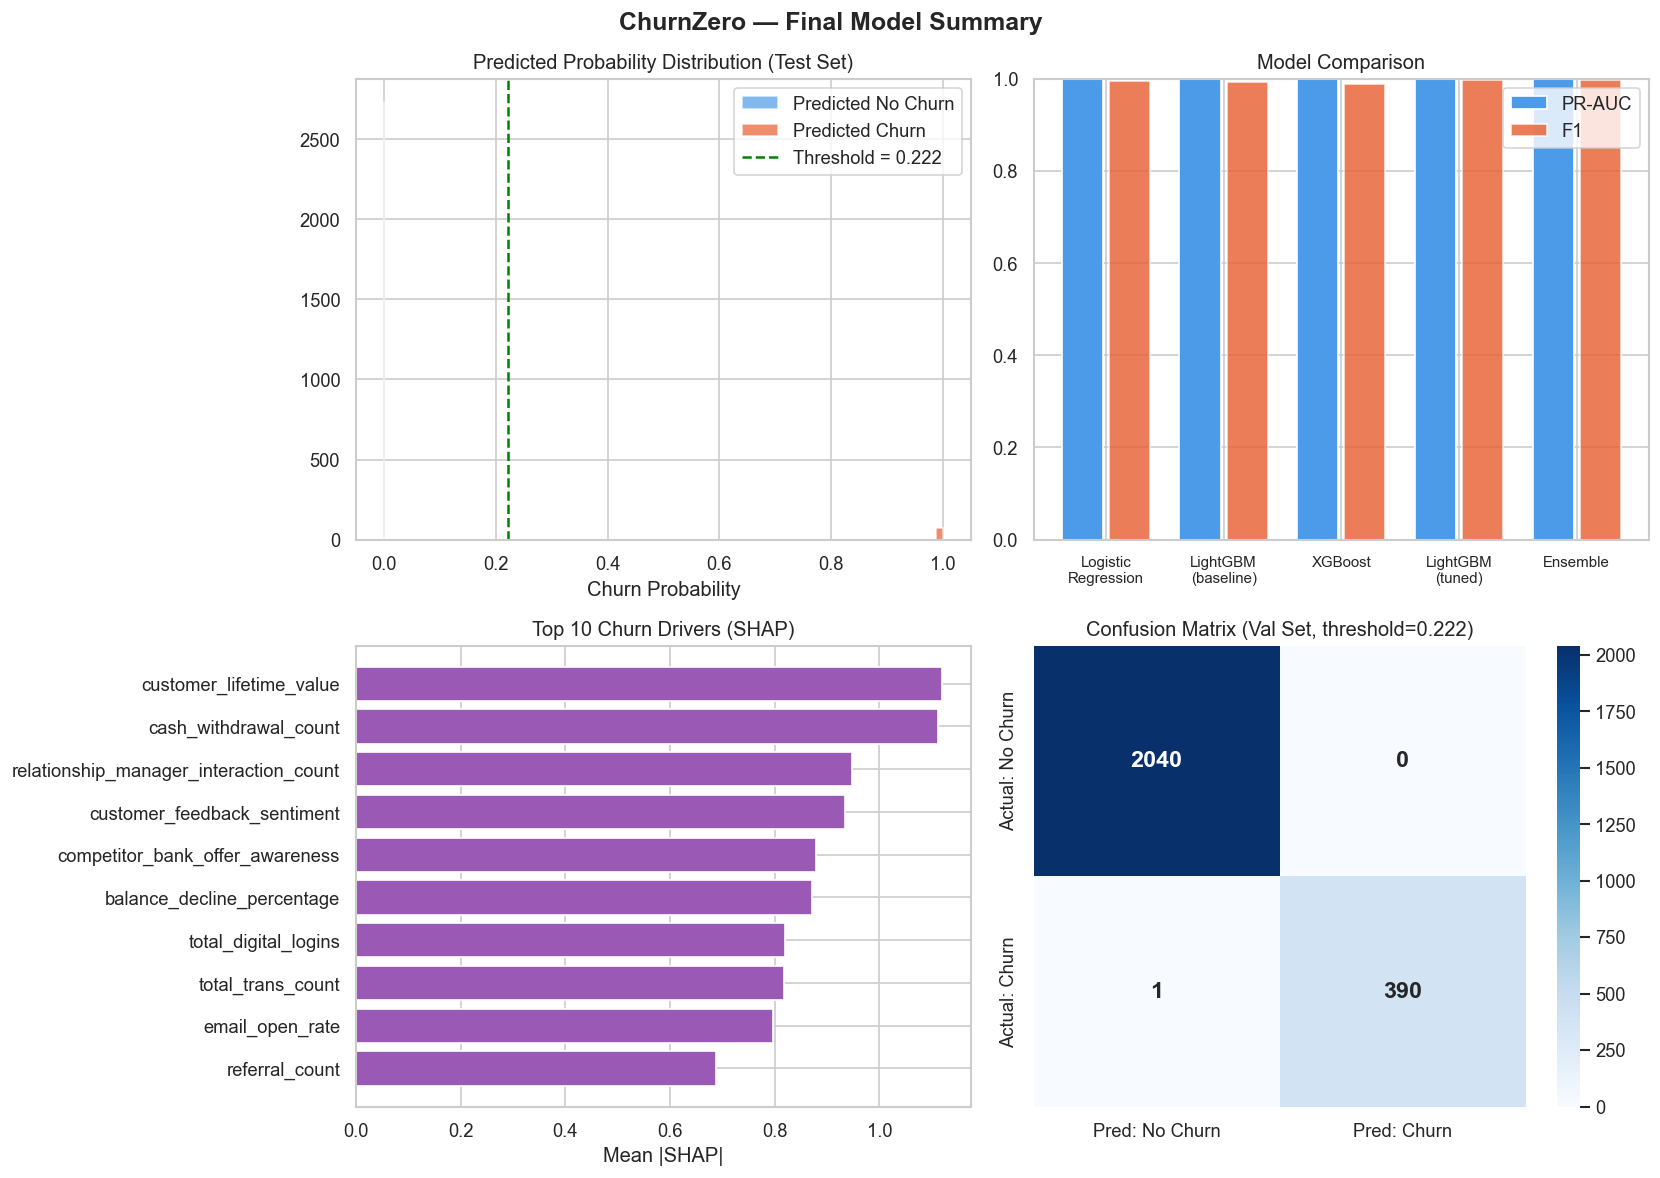

Summary figure saved.

Submission file ready: ChurnZero_Deep Matrix_Predictions.csv


In [30]:
# ── 10.4 Final Summary Dashboard ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted probability distribution
axes[0,0].hist(test_final_proba[test_preds==0], bins=50, alpha=0.7,
               color='#4C9BE8', label='Predicted No Churn', density=True)
axes[0,0].hist(test_final_proba[test_preds==1], bins=50, alpha=0.7,
               color='#E85D30', label='Predicted Churn', density=True)
axes[0,0].axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--',
                  label=f'Threshold = {OPTIMAL_THRESHOLD:.3f}')
axes[0,0].set_title('Predicted Probability Distribution (Test Set)')
axes[0,0].set_xlabel('Churn Probability')
axes[0,0].legend()

# Model performance bar chart
models = ['Logistic\nRegression', 'LightGBM\n(baseline)', 'XGBoost', 'LightGBM\n(tuned)', 'Ensemble']
prauc_scores = [lr_prauc, lgb_prauc, xgb_prauc, best_prauc, blend_prauc]
f1_scores_list = [lr_f1, lgb_f1, xgb_f1, best_f1, blend_f1]
x = np.arange(len(models))
bars1 = axes[0,1].bar(x - 0.2, prauc_scores, 0.35, label='PR-AUC', color='#4C9BE8')
bars2 = axes[0,1].bar(x + 0.2, f1_scores_list, 0.35, label='F1', color='#E85D30', alpha=0.8)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models, fontsize=9)
axes[0,1].set_title('Model Comparison')
axes[0,1].legend()
axes[0,1].set_ylim(0, 1)

# Top 10 SHAP features
top10 = shap_df.head(10)
axes[1,0].barh(top10['feature'][::-1], top10['importance'][::-1], color='#9B59B6')
axes[1,0].set_title('Top 10 Churn Drivers (SHAP)')
axes[1,0].set_xlabel('Mean |SHAP|')

# Confusion matrix
cm_plot = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1,1].set_title(f'Confusion Matrix (Val Set, threshold={OPTIMAL_THRESHOLD:.3f})')

plt.suptitle('ChurnZero — Final Model Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'ChurnZero_{TEAM_NAME}_Summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary figure saved.')
print(f'\nSubmission file ready: ChurnZero_{TEAM_NAME}_Predictions.csv')